# Eval data inspection (new layout)

This notebook replaces `Eval_data_inspection_stats` for the new artifacts written by `eval.py`.

Expected layout:
```
<eval_dir>/
  summary.json
  slim_traces.json
  trees_seed_<seed>.npz
```

Capabilities:
- load many eval dirs into a single table
- pick best checkpoint/run by different metrics
- plot trajectories (replacement for `plot_seeker_trajectory`)
- plot MCTS trees from packed `.npz` (replacement for `plot_mcts_tree_xy_limited`)
- plot step debug view (replacement for `plot_dbg_step`)


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

from plot_utils_eval import (
    load_eval_dir,
    load_packed_trees,
    slice_step_tree,
    plot_seeker_trajectory_slim,
    plot_mcts_tree_xy_limited_np,
    plot_eval_step,
)


## Point this notebook at your results directory

Set `RESULTS_ROOT` to the directory that contains your run folders (the ones that have `eval/<ckpt>` subfolders).


In [2]:
RESULTS_ROOT = Path("runs")  # <- change

# Optional: only include eval directories matching this regex (full path)
EVAL_DIR_NAME_RE = re.compile(r'.*')


## Discover eval directories

We look for folders that contain both a `summary.json` and a `slim_traces.json`.


In [3]:
def find_eval_dirs(results_root: Path):
    eval_dirs = []
    for p in results_root.rglob('summary.json'):
        eval_dir = p.parent
        if (eval_dir / 'slim_traces.json').exists():
            eval_dirs.append(eval_dir)
    eval_dirs = [d for d in eval_dirs if EVAL_DIR_NAME_RE.match(str(d))]
    return sorted(set(eval_dirs))

eval_dirs = find_eval_dirs(RESULTS_ROOT)
print(f"Found {len(eval_dirs)} eval dirs")
eval_dirs[:10]


Found 34 eval dirs


[WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000020000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000040000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000060000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000080000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000100000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000120000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000140000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000160000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000180000'),
 WindowsPath('runs/base__seed42__9567da53/2d/eval/ckpt_step_000200000')]

## Load summaries into a single DataFrame


In [4]:
runs = []
for d in eval_dirs:
    er = load_eval_dir(d)
    s = er.summary

    # infer run/ckpt name from .../<run>/eval/<ckpt>
    parts = er.eval_dir.parts
    run_name = parts[-3] if len(parts) >= 3 else str(er.eval_dir)
    ckpt_name = parts[-1]

    runs.append({
        'run': run_name,
        'ckpt': ckpt_name,
        'eval_dir': str(er.eval_dir),
        'checkpoint': s.get('checkpoint'),
        'step': s.get('step'),
        'env_variant': s.get('env_variant'),
        'num_seeds': s.get('num_seeds'),
        'max_steps': s.get('max_steps'),
        'tree_state_mode': s.get('tree_state_mode'),
        'return_mean': s.get('return_mean'),
        'return_std': s.get('return_std'),
        'success_rate': s.get('success_rate'),
        'crash_rate': s.get('crash_rate'),
    })

df = pd.DataFrame(runs)
if len(df):
    df = df.sort_values(['run', 'step']).reset_index(drop=True)
df


,run,ckpt,eval_dir,checkpoint,step,env_variant,num_seeds,max_steps,tree_state_mode,return_mean,return_std,success_rate,crash_rate
0,2d,ckpt_step_000020000,runs\base__seed42__9567da53\2d\eval\ckpt_step_...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,20000,2d,50,300,full,4.0,19.595919,0.04,0.0
1,2d,ckpt_step_000020000,runs\bootstrap_at_40k__seed42__976901ee\2d\eva...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,20000,2d,50,300,full,8.0,27.129320,0.08,0.0
2,2d,ckpt_step_000020000,runs\cpuct_0p2__seed42__4557fede\2d\eval\ckpt_...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,20000,2d,50,300,full,8.0,27.129320,0.08,0.0
3,2d,ckpt_step_000040000,runs\base__seed42__9567da53\2d\eval\ckpt_step_...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,40000,2d,50,300,full,6.0,23.748684,0.06,0.0
4,2d,ckpt_step_000040000,runs\bootstrap_at_40k__seed42__976901ee\2d\eva...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,40000,2d,50,300,full,4.0,19.595919,0.04,0.0
5,2d,ckpt_step_000040000,runs\cpuct_0p2__seed42__4557fede\2d\eval\ckpt_...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,40000,2d,50,300,full,2.0,14.000000,0.02,0.0
6,2d,ckpt_step_000040000,runs\cpuct_20__seed42__49a8b2b7\2d\eval\ckpt_s...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,40000,2d,50,300,full,10.0,30.000000,0.10,0.0
7,2d,ckpt_step_000060000,runs\base__seed42__9567da53\2d\eval\ckpt_step_...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,60000,2d,50,300,full,4.0,19.595919,0.04,0.0
8,2d,ckpt_step_000060000,runs\bootstrap_at_40k__seed42__976901ee\2d\eva...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,60000,2d,50,300,full,6.0,23.748684,0.06,0.0
9,2d,ckpt_step_000060000,runs\cpuct_0p2__seed42__4557fede\2d\eval\ckpt_...,C:\Users\timok\Desktop\rl_challenge\rl-comptet...,60000,2d,50,300,full,4.0,19.595919,0.04,0.0


### Best checkpoint selection helpers


In [5]:
def pick_best(df: pd.DataFrame, metric: str = 'success_rate', *, group_by_run: bool = False):
    if len(df) == 0:
        raise RuntimeError('No eval dirs found (df is empty).')
    if metric not in df.columns:
        raise KeyError(f"metric {metric} not in columns: {list(df.columns)}")

    if group_by_run:
        out = df.loc[df.groupby('run')[metric].idxmax()].sort_values(metric, ascending=False)
        return out

    idx = df[metric].astype(float).idxmax()
    return df.loc[idx]

best_overall = pick_best(df, metric='success_rate', group_by_run=False)
best_overall


run                                                               2d
ckpt                                             ckpt_step_000040000
eval_dir           runs\cpuct_20__seed42__49a8b2b7\2d\eval\ckpt_s...
checkpoint         C:\Users\timok\Desktop\rl_challenge\rl-comptet...
step                                                           40000
env_variant                                                       2d
num_seeds                                                         50
max_steps                                                        300
tree_state_mode                                                 full
return_mean                                                     10.0
return_std                                                      30.0
success_rate                                                     0.1
crash_rate                                                       0.0
Name: 6, dtype: object

## Inspect per-seed results for one eval directory


In [6]:
row = best_overall

eval_dir = Path(row['eval_dir'])
er = load_eval_dir(eval_dir)

print('Eval dir:', er.eval_dir)
print('Checkpoint:', er.summary.get('checkpoint'))
print('Step:', er.summary.get('step'))
print('Env:', er.summary.get('env_variant'))
print('Seeds:', len(er.slim_traces))
print('Available tree files:', len(er.trees_by_seed))

seed_df = pd.DataFrame(er.summary.get('per_seed', []))
seed_df = seed_df.sort_values('total_return', ascending=False).reset_index(drop=True)
seed_df


Eval dir: runs\cpuct_20__seed42__49a8b2b7\2d\eval\ckpt_step_000040000
Checkpoint: C:\Users\timok\Desktop\rl_challenge\rl-comptetition\PSRL---AlphaZero-implementation\runs\cpuct_20__seed42__49a8b2b7\2d\checkpoints\ckpt_step_000040000.pt
Step: 40000
Env: 2d
Seeds: 50
Available tree files: 50


,seed,ep_len,total_return,terminated_goal,terminated_crash,terminated_timeout
0,1000,97,100.0,True,False,False
1,1048,18,100.0,True,False,False
2,1010,28,100.0,True,False,False
3,1001,63,100.0,True,False,False
4,1002,130,100.0,True,False,False
5,1047,150,0.0,False,False,True
6,1036,150,0.0,False,False,True
7,1028,150,0.0,False,False,True
8,1029,150,0.0,False,False,True
9,1030,150,0.0,False,False,True


### Plot a trajectory (slim trace)


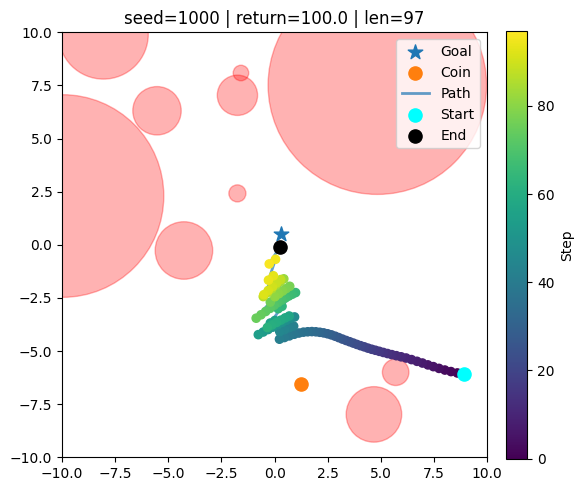

In [7]:
best_seed = int(seed_df.iloc[0]['seed']) if len(seed_df) else int(er.slim_traces[0]['seed'])
slim = next(s for s in er.slim_traces if int(s['seed']) == best_seed)

plot_seeker_trajectory_slim(
    slim,
    title=f"seed={best_seed} | return={slim['total_return']:.1f} | len={slim['ep_len']}",
    L=10,
)


### Plot an MCTS tree at a specific step

This uses `trees_seed_<seed>.npz` if present.


<Axes: title={'center': 'seed=1000 | step=0'}>

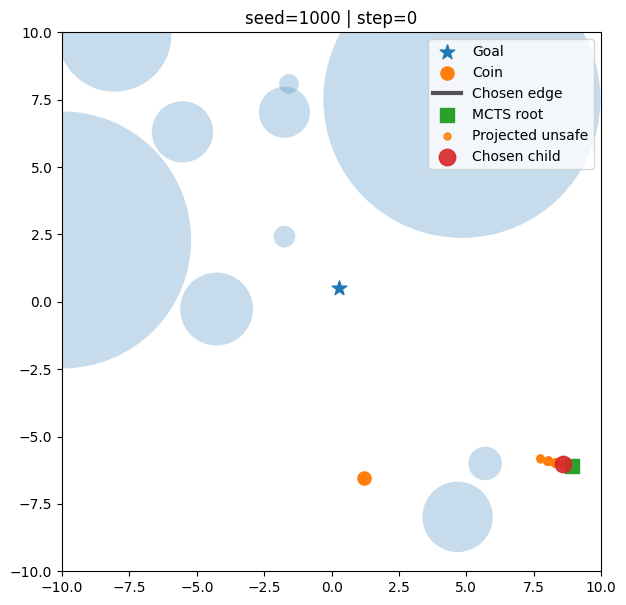

In [8]:
seed = best_seed
step = 0

npz_path = er.trees_by_seed.get(int(seed))
if npz_path is None:
    raise FileNotFoundError(f"No trees file for seed={seed} in {er.eval_dir}")

packed = load_packed_trees(npz_path)
tree0 = slice_step_tree(packed, step)

chosen_idx = None
if 'chosen_idx' in slim and step < len(slim['chosen_idx']):
    chosen_idx = int(slim['chosen_idx'][step])

plot_mcts_tree_xy_limited_np(
    tree0,
    num_obstacles=len(slim.get('obstacles', [])),
    slim=slim,
    L=10,
    max_depth=6,
    top_k_per_node=5,
    chosen_child_idx=chosen_idx,
    title=f"seed={seed} | step={step}",
)


### Plot a debug-style step view (trajectory up to k + tree at k)


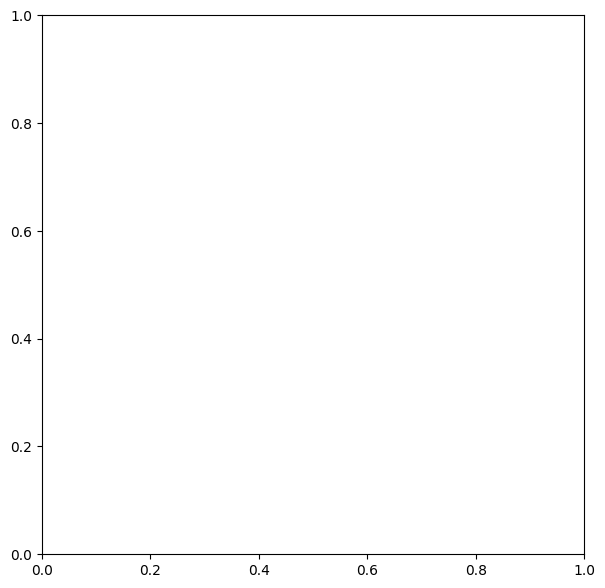

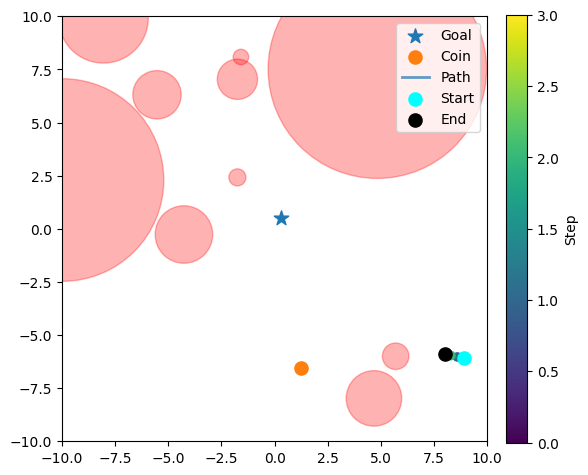

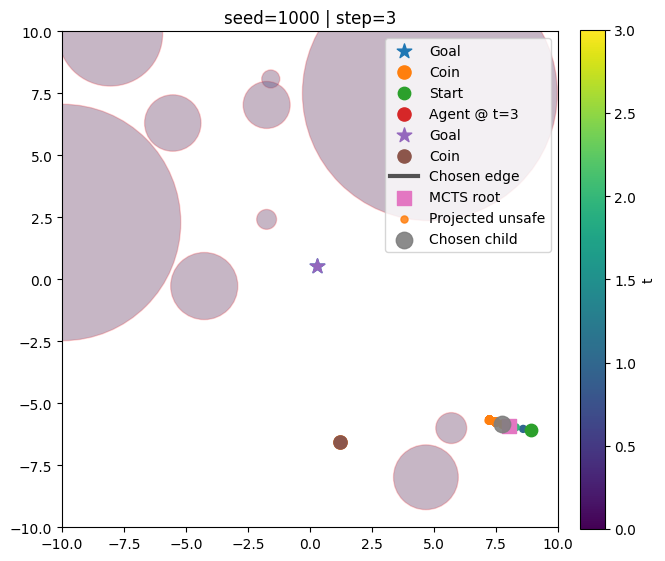

In [9]:
k = 3

tree_k = slice_step_tree(packed, k)
plot_eval_step(
    slim,
    tree_k,
    k,
    num_obstacles=len(slim.get('obstacles', [])),
    L=10,
    max_depth=6,
    top_k_per_node=5,
    title=f"seed={seed} | step={k}",
)


## Interactive explorer

If you have `ipywidgets` installed, you can interactively browse seeds and steps.


In [10]:
try:
    from ipywidgets import interact, IntSlider, Dropdown
except Exception as e:
    raise RuntimeError('ipywidgets not installed in this environment') from e

seed_options = sorted([int(s['seed']) for s in er.slim_traces])

@interact(
    seed=Dropdown(options=seed_options, value=seed_options[0], description='seed'),
    k=IntSlider(min=0, max=50, step=1, value=0, description='step'),
)
def _view(seed, k):
    slim = next(s for s in er.slim_traces if int(s['seed']) == int(seed))
    npz_path = er.trees_by_seed.get(int(seed))
    if npz_path is None:
        print(f"No trees file for seed={seed}")
        plot_seeker_trajectory_slim(slim, title=f"seed={seed}", L=10)
        return

    packed = load_packed_trees(npz_path)
    # trees are stored per action step (0..ep_len-1); agent_pos has length ep_len+1
    max_k = int(slim['ep_len']) - 1
    k = int(max(0, min(k, max_k)))

    tree_k = slice_step_tree(packed, k)
    plot_eval_step(
        slim,
        tree_k,
        k,
        num_obstacles=len(slim.get('obstacles', [])),
        L=10,
        max_depth=6,
        top_k_per_node=5,
        title=f"seed={seed} | step={k}",
    )


interactive(children=(Dropdown(description='seed', options=(1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 10…